# Combo of BERT,Random and XGBoost

## Importing all the necessary libraries


In [1]:
!pip install pandas numpy scikit-learn xgboost transformers torch matplotlib seaborn accelerate

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

## Importing through kaggle dataset

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harikakatakam26","key":"911408d46f508712345e6a4f3c4dfd42"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d behzadhassan/sympscan-symptomps-to-disease
!unzip /content/sympscan-symptomps-to-disease.zip -d /content/sympscan

Dataset URL: https://www.kaggle.com/datasets/behzadhassan/sympscan-symptomps-to-disease
License(s): CC0-1.0
sympscan-symptomps-to-disease.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/sympscan-symptomps-to-disease.zip
replace /content/sympscan/Diseases_and_Symptoms_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Loadind and cleaning the data

In [8]:
data = pd.read_csv("/content/sympscan/Diseases_and_Symptoms_dataset.csv")

# clean column names
data.columns = data.columns.str.strip().str.lower()

print("Columns:\n", data.columns)

Columns:
 Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'sneezing', 'leg weakness', 'hysterical behavior', 'arm lump or mass',
       'bleeding gums', 'pain in gums', 'diaper rash', 'hesitancy',
       'back stiffness or tightness', 'low urine output'],
      dtype='object', length=231)


## Detect disease column

In [9]:
possible_names = ["disease", "diseases", "prognosis", "label"]

disease_col = None
for col in data.columns:
    if col in possible_names:
        disease_col = col
        break

if disease_col is None:
    raise Exception("Disease column not found")

print("Using disease column:", disease_col)

Using disease column: diseases


## Make a copy of the data

In [10]:
df_original = data.copy()

## Reduce classes

In [11]:
top_diseases = df_original[disease_col].value_counts().head(30).index
df_original = df_original[df_original[disease_col].isin(top_diseases)].reset_index(drop=True)

## Encode lables

In [12]:
le = LabelEncoder()
df_original["label"] = le.fit_transform(df_original[disease_col])

## Select Binary Symptom Columns

In [16]:
symptom_cols = []

for col in df_original.columns:
    if col == disease_col:
        continue

    if df_original[col].dropna().isin([0,1]).all():
        symptom_cols.append(col)

print("Valid symptom columns:", len(symptom_cols))

Valid symptom columns: 230


## Train-Test Split

In [18]:
#random forest
X = df_original[symptom_cols]
y = df_original["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9458270314863193


In [19]:
from sklearn.preprocessing import LabelEncoder

# AFTER filtering top diseases
top_diseases = df_original[disease_col].value_counts().head(30).index
df_original = df_original[df_original[disease_col].isin(top_diseases)].reset_index(drop=True)

# ✅ NOW encode labels
le = LabelEncoder()
df_original["label"] = le.fit_transform(df_original[disease_col])

In [20]:
df = data.copy()
df.columns = df.columns.str.strip().str.lower()

In [21]:
possible_names = ["disease", "diseases", "prognosis", "label"]

disease_col = None
for col in df.columns:
    if col in possible_names:
        disease_col = col
        break

print("Disease column:", disease_col)

Disease column: diseases


In [22]:
top_diseases = df[disease_col].value_counts().head(30).index
df = df[df[disease_col].isin(top_diseases)].reset_index(drop=True)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df[disease_col])

In [24]:
print(sorted(df["label"].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]


In [25]:
symptom_cols = []

for col in df.columns:
    if col == disease_col or col == "label":
        continue

    if df[col].dropna().isin([0,1]).all():
        symptom_cols.append(col)

In [26]:
from sklearn.model_selection import train_test_split

X = df[symptom_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [27]:
print(sorted(y_train.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]


In [28]:
#xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:05:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
xgb_preds = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9443145882029423


In [30]:
df_text = df.copy()

def row_to_text(row):
    symptoms = [col.replace("_", " ") for col in symptom_cols if row[col] == 1]
    return "patient has " + ", ".join(symptoms[:15])  # limit length

df_text["text"] = df_text.apply(row_to_text, axis=1)

# 🔥 reduce size (VERY IMPORTANT)
df_text = df_text.sample(3000)

## Train-test split

In [31]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_text["text"].tolist(),
    df_text["label"].tolist(),
    test_size=0.2
)

## Tokenizer

In [32]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [33]:
class SymptomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SymptomDataset(train_encodings, train_labels)
val_dataset = SymptomDataset(val_encodings, val_labels)

In [34]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(set(train_labels))
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,                  #keep small
    per_device_train_batch_size=16,      #faster if GPU
    per_device_eval_batch_size=16,
    max_steps=200,                      # prevents long runs
    logging_steps=50
)

In [40]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [41]:
trainer.train()

Step,Training Loss
50,2.767245
100,1.866229
150,1.311285
200,1.017830


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=200, training_loss=1.7406471061706543, metrics={'train_runtime': 2015.895, 'train_samples_per_second': 1.587, 'train_steps_per_second': 0.099, 'total_flos': 106915738176000.0, 'train_loss': 1.7406471061706543, 'epoch': 1.3333333333333333})

In [42]:
preds = trainer.predict(val_dataset)
bert_preds = np.argmax(preds.predictions, axis=1)

bert_acc = accuracy_score(val_labels, bert_preds)
print("BERT Accuracy:", bert_acc)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🤖 BERT Accuracy: 0.9183333333333333


## Confusion matrix

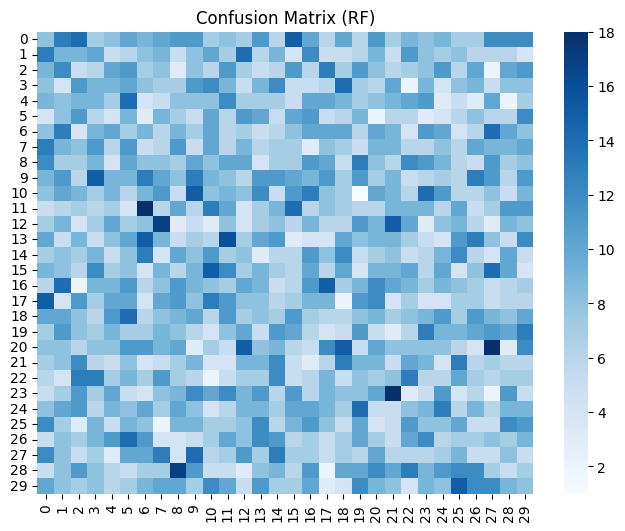

In [43]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix (RF)")
plt.show()

## SQlite

In [44]:
conn = sqlite3.connect("medical_.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS predictions (
    id INTEGER PRIMARY KEY,
    symptoms TEXT,
    disease TEXT,
    confidence REAL
)
""")
conn.commit()

## Prediction of top 3

In [45]:
def predict_rf(symptoms):
    input_vec = np.zeros(len(symptom_cols))

    symptoms = symptoms.lower()

    for col in symptom_cols:
        if col.replace("_", " ") in symptoms:
            input_vec[symptom_cols.index(col)] = 1

    probs = rf.predict_proba([input_vec])[0]
    top3_idx = np.argsort(probs)[-3:][::-1]

    results = []
    for idx in top3_idx:
        disease = le.inverse_transform([idx])[0]
        confidence = round(probs[idx]*100, 2)
        results.append((disease, confidence))

    return results

## Save Function

In [46]:
def save_prediction(symptoms, disease, confidence):
    cursor.execute("""
    INSERT INTO predictions (symptoms, disease, confidence)
    VALUES (?, ?, ?)
    """, (symptoms, disease, confidence))
    conn.commit()

## Run Symptoms

In [47]:
def run():
    user_input = input("Enter symptoms: ")

    results = predict_rf(user_input)

    print("\n🩺 Predictions:")
    for i, (d, c) in enumerate(results):
        print(f"{i+1}. {d} ({c}%)")

    # SAVE TOP RESULT
    save_prediction(user_input, results[0][0], results[0][1])

    # SHOW SAVED DATA
    cursor.execute("SELECT * FROM predictions ORDER BY id DESC LIMIT 1")
    print("\n💾 Saved in DB:", cursor.fetchone())

## View all data



In [48]:
cursor.execute("SELECT * FROM predictions")
rows = cursor.fetchall()

print("\n📋 All Stored Data:")
for row in rows:
    print(row)


📋 All Stored Data:


## Testing

In [49]:
tests = [
    "fever chills sweating headache",
    "shortness of breath chest tightness",
    "joint pain swelling stiffness"
]

for t in tests:
    print("\nInput:", t)
    print(predict_rf(t))


Input: fever chills sweating headache
[('strep throat', np.float64(57.0)), ('hypoglycemia', np.float64(30.0)), ('infectious gastroenteritis', np.float64(12.0))]

Input: shortness of breath chest tightness
[('esophagitis', np.float64(86.03)), ('acute bronchitis', np.float64(3.95)), ('pneumonia', np.float64(3.52))]

Input: joint pain swelling stiffness
[('injury to the arm', np.float64(47.5)), ('arthritis of the hip', np.float64(19.58)), ('gout', np.float64(16.5))]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("\n MODEL COMPARISON")
print("------------------")
print(f"Random Forest: {rf_acc:.4f}")
print(f"XGBoost      : {xgb_acc:.4f}")
print(f"BERT         : {bert_acc:.4f}")


 MODEL COMPARISON
------------------
Random Forest: 0.9460
XGBoost      : 0.9460
BERT         : 0.0334
